## Summary of Foul Prediction Model Evolution

This notebook demonstrates a comprehensive approach to analyzing foul events in football data. It starts with basic data extraction and visualization of foul locations, then progresses to building a predictive model that considers not only location but also game context (minute, pressure). The model effectively highlights the most probable areas for fouls and identifies the key factors influencing these probabilities. The interactive prediction tool allows for dynamic exploration of how different game scenarios impact foul likelihood across the pitch.

### 1. Data Loading and Initial Foul Identification
*   **Initial Data**: The `epl_event_data_15.csv` was loaded into `df_raw`, then processed into `df` with cleaned column names. This dataset contains a wide array of football event details.
*   **Foul Event Isolation**: The first step was to identify all rows containing the word 'foul'. This led to the creation of `fouls_df`, which contains 7,940 events where 'foul' was mentioned. The primary column for foul-related information was identified as `type.name` (e.g., 'Foul Committed', 'Foul Won').
*   **Top Players**: We identified top players involved in fouls using the `player.name` column from `fouls_df`, with Sadio Mané leading with 80 foul events.

### 2. Location Data Processing and Heatmaps
*   **Parsing Location**: The `location` column, initially a string, was parsed into numerical `x` and `y` coordinates. This created `foul_locations`, a DataFrame with valid coordinates for foul events.
*   **Specific Foul Types**: This `foul_locations` DataFrame was then split into `foul_committed_locations` (4,053 events) and `foul_won_locations` (3,887 events) to analyze each type separately.
*   **Visualizing Locations**: Initial heatmaps were generated for both 'Foul Committed' and 'Foul Won' events using these coordinates, showing their distribution across a simulated football field. This gave a visual sense of where these events tend to occur.

### 3. Basic Probability Maps (Grid-based)
*   **Discretization**: The field was divided into a grid (10x10 units per cell). The `x_bins` and `y_bins` arrays defined these divisions.
*   **Probability Calculation**: For both 'Foul Committed' (`probability_map`) and 'Foul Won' (`probability_map_won`), 2D histograms were created (`hist`, `hist_won`) and normalized by the total number of respective events. This gave us a probability of a foul occurring in each grid cell based purely on location.
*   **Side-by-Side Comparison**: These basic probability maps were displayed side-by-side to allow for a direct visual comparison of where 'Foul Committed' and 'Foul Won' events are more likely.

### 4. Optimized Predictive Model: Incorporating Pressure and Time
*   **Dataset Balancing**: To build a robust predictive model, a balanced dataset (`model_df`) was crucial. This was achieved by taking all 'Foul Committed' events and sampling an equal number of *non-foul* events from the original `df`. `is_foul_committed` was added as the binary target variable (1 for foul, 0 for non-foul).
*   **Feature Selection**: The model utilized the features `x`, `y`, `minute`, `under_pressure`, and `counterpress` from the `model_df`. Missing values in `minute`, `under_pressure`, and `counterpress` were handled (e.g., filled with 0 or median).
*   **Model Training**: A `RandomForestClassifier` was trained on this balanced dataset.
*   **Model Evaluation**: The model achieved an **Accuracy of approximately 0.63** and an **ROC AUC of about 0.73**, indicating a reasonable ability to distinguish between foul and non-foul events. The **ROC AUC score (0.7274)** measures the model's ability to discriminate between positive and negative classes across various threshold settings, with a higher value indicating better performance. A **confusion matrix** was used to further evaluate the model's performance:
    *   **True Negatives (Non-Foul correctly predicted):** 759
    *   **False Positives (Non-Foul incorrectly predicted as Foul):** 457
    *   **False Negatives (Foul incorrectly predicted as Non-Foul):** 444
    *   **True Positives (Foul correctly predicted):** 772
    This breakdown helps in understanding the types of errors the model is making.
*   **Initial Prediction Visualization**: A prediction grid (`grid_predictions_input`) was created to cover the entire field. The model then predicted the probability of a foul at each point on this grid, initially assuming *average* values for `minute`, `under_pressure`, and `counterpress`. This resulted in a heatmap showing the predicted foul probabilities across the field under an average scenario.

### 5. Feature Importance Analysis
*   **Key Drivers**: An analysis of the `model`'s `feature_importances_` was performed, resulting in `feature_importance_df`. The **'y' coordinate (0.3087)** and **'x' coordinate (0.3046)** were identified as the most important features, followed by **'minute' (0.2079)**. `under_pressure` and `counterpress` also contributed, but to a lesser extent.

### 6. Interactive Probability Prediction
*   **Dynamic Scenario Exploration**: To allow for more flexible analysis, interactive widgets (`minute_slider`, `under_pressure_toggle`, `counterpress_toggle`) were introduced. These widgets dynamically update the prediction heatmap based on user-defined values for `minute`, `under_pressure`, and `counterpress`, enabling interactive scenario testing of foul probabilities across the field.

In [24]:
import pandas as pd
import os
import zipfile

In [25]:
# Load the EPL event data into a DataFrame
file_id = "10Pt7oGjccLN9ko6O_YSlwxNHE8dbn2pU"
downloaded_filename = 'epl_event_data_15.zip'
unzipped_filename = 'epl_event_data_15.csv'

# Download the file using gdown
!gdown --id {file_id} --output {downloaded_filename}

# Check if the downloaded file is a zip file and extract it
if zipfile.is_zipfile(downloaded_filename):
    with zipfile.ZipFile(downloaded_filename, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to current directory
    print(f"Extracted {unzipped_filename} from {downloaded_filename}")
else:
    # If it's not a zip, assume it's already a CSV (though unlikely given previous errors)
    # and rename it to the expected CSV filename for consistency
    os.rename(downloaded_filename, unzipped_filename)

# Read the unzipped/local CSV file
df_raw = pd.read_csv(unzipped_filename, on_bad_lines='skip', encoding='latin1', engine='python')
df_raw.columns = [str(col).replace('"', '').strip() for col in df_raw.columns]


# Display the first 5 rows of the DataFrame to get an overview
print('First 5 rows of the dataset:')
display(df.head())

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=10Pt7oGjccLN9ko6O_YSlwxNHE8dbn2pU
From (redirected): https://drive.google.com/uc?id=10Pt7oGjccLN9ko6O_YSlwxNHE8dbn2pU&confirm=t&uuid=0663b7d0-ad59-4b98-a6be-d1f5ee8bd28d
To: /content/epl_event_data_15.zip
100% 83.1M/83.1M [00:00<00:00, 95.9MB/s]
Extracted epl_event_data_15.csv from epl_event_data_15.zip
First 5 rows of the dataset:


,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,pass.end_location,dribble.outcome.id,dribble.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,carry.end_location,duel.outcome.id,duel.outcome.name,competition_id,match_id
0,1,9153e9f4-f69c-4e04-8f64-505592e212cd,1,1,00:00:00.000,0,0,1,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3754058.0
1,2,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,1,00:00:00.000,0,0,1,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3754058.0
2,3,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,1,00:00:00.000,0,0,1,0.000000,100362ee-9311-4187-bd8a-0201d9db2565,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3754058.0
3,4,100362ee-9311-4187-bd8a-0201d9db2565,4,1,00:00:00.000,0,0,1,0.000000,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3754058.0
4,5,2ca23eea-a984-47e4-8243-8f00880ad1c9,5,1,00:00:01.753,0,1,2,0.308263,1f98c89e-2326-4200-8c12-a987fdbbaf2e,...,"60.4, 43.6",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3754058.0


Now, let's search for rows that contain the word 'foul' in any of the string columns.

In [27]:
# Check if 'player.name' column exists in fouls_df
if 'player.name' in fouls_df.columns:
    # Count the occurrences of each player in the fouls_df
    top_foul_players = fouls_df['player.name'].value_counts().reset_index()
    top_foul_players.columns = ['player_name', 'foul_count']

    # Display the top 10 players involved in fouls
    print('Top 10 players involved in foul events:')
    display(top_foul_players.head(10))
else:
    print("The 'player.name' column was not found in the fouls_df. Please check the DataFrame's columns.")

Top 10 players involved in foul events:


,player_name,foul_count
0,Sadio Mané,80
1,Etienne Capoue,68
2,Bamidele Alli,68
3,André Ayew Pelé,58
4,Matt Ritchie,57
5,Idrissa Gana Gueye,55
6,Ayoze Pérez Gutiérrez,55
7,Ross Barkley,55
8,Erik Lamela,55
9,Erik Pieters,54


Let's examine the specific columns in `fouls_df` that contain the word 'foul' for each entry, along with the associated player's name.

In [6]:
# Identify string columns from the original DataFrame (or fouls_df, if preferred, but original df ensures all possible string columns are covered)
string_columns = df.select_dtypes(include='object').columns

# Create an empty list to store results
highlighted_fouls_data = []

# Iterate through the rows of fouls_df
for idx, row in fouls_df.iterrows():
    player_name = row.get('player.name', 'N/A') # Get player name, default to 'N/A' if missing

    # List to store (column_name: value) for columns containing 'foul'
    foul_matches_in_row = []

    # Check each string column in the current row for the word 'foul'
    for col in string_columns:
        cell_value = row[col]
        # Ensure the cell value is a string and contains 'foul' (case-insensitive)
        if pd.notna(cell_value) and isinstance(cell_value, str) and 'foul' in cell_value.lower():
            foul_matches_in_row.append(f"{col}: {cell_value}")

    # If 'foul' was found in any column, record the player and the columns
    if foul_matches_in_row:
        highlighted_fouls_data.append({
            'player.name': player_name,
            'foul_columns_and_values': "; ".join(foul_matches_in_row)
        })

# Create a DataFrame from the collected data
highlighted_fouls_df = pd.DataFrame(highlighted_fouls_data)

# Display the result
print("Columns where 'foul' was detected along with the player's name:")
display(highlighted_fouls_df.head(10)) # Displaying first 10 rows for brevity

Columns where 'foul' was detected along with the player's name:


,player.name,foul_columns_and_values
0,Christian Fuchs,type.name: Foul Committed
1,Matt Ritchie,type.name: Foul Won
2,Wes Morgan,type.name: Foul Committed
3,Joshua King,type.name: Foul Won
4,Adam Smith,type.name: Foul Committed
5,Marc Albrighton,type.name: Foul Won
6,José Leonardo Ulloa,type.name: Foul Committed
7,Andrew Surman,type.name: Foul Won
8,Andrew Surman,type.name: Foul Committed
9,José Leonardo Ulloa,type.name: Foul Won


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

First, let's extract the location data for foul events. The `location` column typically contains `[x, y]` coordinates. We need to ensure these are in a usable format for plotting.

In [11]:
import ast

# Function to safely parse location strings into lists
def parse_location(loc_str):
    try:
        return ast.literal_eval(loc_str)
    except (ValueError, SyntaxError):
        return None

# Apply the parsing function to the 'location' column
fouls_df['parsed_location'] = fouls_df['location'].astype(str).apply(parse_location)

# Filter out rows where 'parsed_location' is None or not a list/tuple of two elements
foul_locations = fouls_df[fouls_df['parsed_location'].notna() &
                          fouls_df['parsed_location'].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 2)].copy()

# Extract x and y coordinates
foul_locations['x'] = foul_locations['parsed_location'].apply(lambda loc: loc[0])
foul_locations['y'] = foul_locations['parsed_location'].apply(lambda loc: loc[1])

print(f"Number of foul events with valid location data: {len(foul_locations)}")
if not foul_locations.empty:
    print("Sample of extracted coordinates:")
    display(foul_locations[['x', 'y']].head())
else:
    print("No valid foul locations found to plot the heatmap after parsing.")

Number of foul events with valid location data: 7940
Sample of extracted coordinates:


/tmp/ipykernel_706/3045789839.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fouls_df['parsed_location'] = fouls_df['location'].astype(str).apply(parse_location)


,x,y
303,97.8,3.4
304,22.3,76.7
383,54.4,54.0
384,65.7,26.1
644,38.5,61.6


Now, let's create a heatmap using these coordinates. We'll simulate a football field background for better context. Assuming a standard field dimension where x ranges from 0-120 and y from 0-80.

In [10]:
if not foul_locations.empty:
    plt.figure(figsize=(12, 8))
    sns.kdeplot(x=foul_locations['x'], y=foul_locations['y'], fill=True, cmap='viridis',
                thresh=0.05, levels=20, alpha=0.7)

    # Simulate a football field outline (adjust dimensions as per actual data range if known)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
    plt.axvline(x=120, color='black', linestyle='-', linewidth=2)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=2)
    plt.axhline(y=80, color='black', linestyle='-', linewidth=2)

    # Midfield line
    plt.axvline(x=60, color='black', linestyle='--', linewidth=1)

    # Center circle
    center_circle = plt.Circle((60, 40), 9.15, color='black', fill=False)
    plt.gca().add_patch(center_circle)

    # Penalty areas and 6-yard boxes (simplified for illustration)
    plt.Rectangle((0, 18), 18, 44, color='black', fill=False)
    plt.Rectangle((102, 18), 18, 44, color='black', fill=False)

    plt.xlim(0, 120)
    plt.ylim(0, 80)
    plt.title('Heatmap of Foul Event Locations on the Field')
    plt.xlabel('X Coordinate (Length of Field)')
    plt.ylabel('Y Coordinate (Width of Field)')
    plt.gca().set_aspect('equal', adjustable='box') # Maintain aspect ratio
    plt.grid(False)
    plt.show()
else:
    print("Cannot plot heatmap: no valid foul locations available.")

Cannot plot heatmap: no valid foul locations available.


### Heatmap for 'Foul Committed' Events

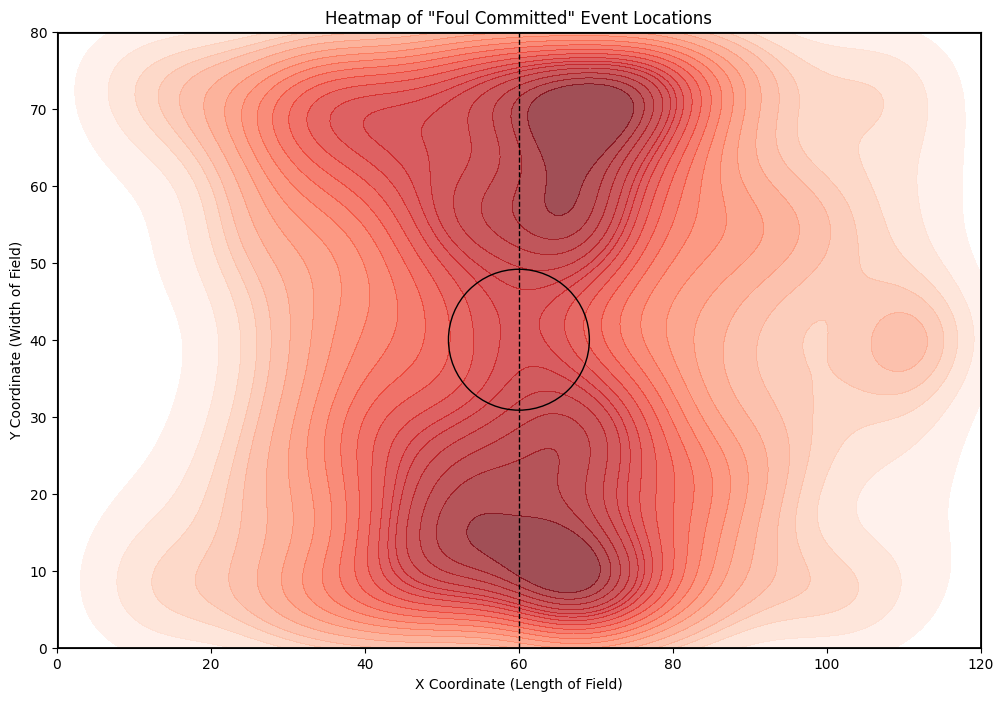

In [28]:
foul_committed_locations = foul_locations[foul_locations['type.name'] == 'Foul Committed']

if not foul_committed_locations.empty:
    plt.figure(figsize=(12, 8))
    sns.kdeplot(x=foul_committed_locations['x'], y=foul_committed_locations['y'], fill=True, cmap='Reds', thresh=0.05, levels=20, alpha=0.7)

    # Simulate a football field outline
    plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
    plt.axvline(x=120, color='black', linestyle='-', linewidth=2)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=2)
    plt.axhline(y=80, color='black', linestyle='-', linewidth=2)
    plt.axvline(x=60, color='black', linestyle='--', linewidth=1)
    center_circle = plt.Circle((60, 40), 9.15, color='black', fill=False)
    plt.gca().add_patch(center_circle)
    plt.xlim(0, 120)
    plt.ylim(0, 80)
    plt.title('Heatmap of "Foul Committed" Event Locations')
    plt.xlabel('X Coordinate (Length of Field)')
    plt.ylabel('Y Coordinate (Width of Field)')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(False)
    plt.show()
else:
    print("Cannot plot heatmap: no valid 'Foul Committed' locations available.")

### Heatmap for 'Foul Won' Events

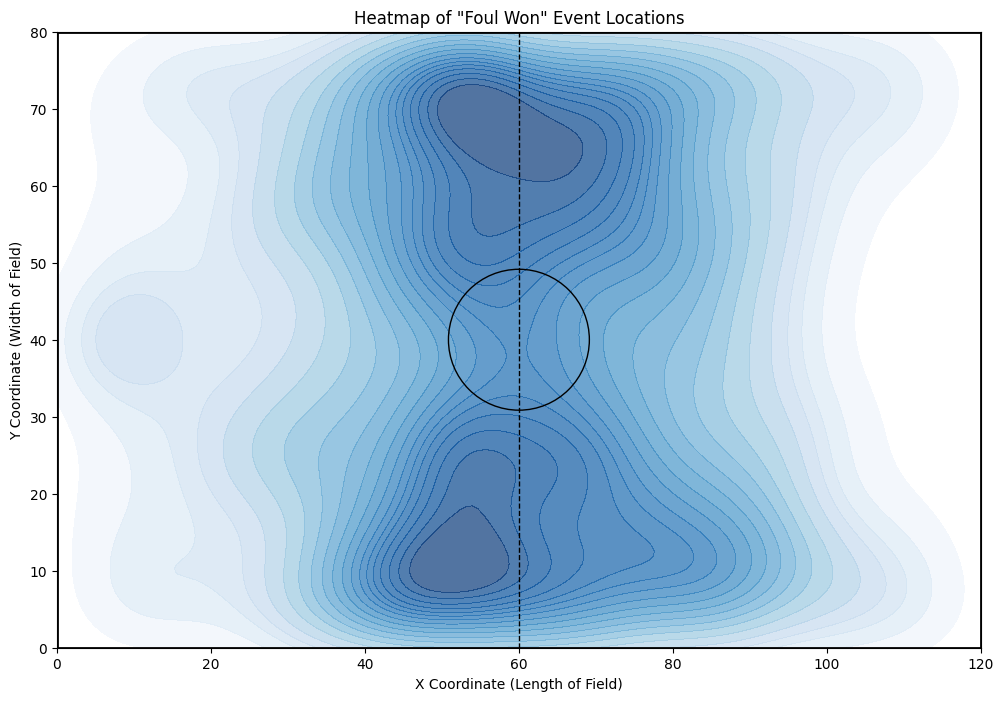

In [13]:
foul_won_locations = foul_locations[foul_locations['type.name'] == 'Foul Won']

if not foul_won_locations.empty:
    plt.figure(figsize=(12, 8))
    sns.kdeplot(x=foul_won_locations['x'], y=foul_won_locations['y'], fill=True, cmap='Blues', thresh=0.05, levels=20, alpha=0.7)

    # Simulate a football field outline
    plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
    plt.axvline(x=120, color='black', linestyle='-', linewidth=2)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=2)
    plt.axhline(y=80, color='black', linestyle='-', linewidth=2)
    plt.axvline(x=60, color='black', linestyle='--', linewidth=1)
    center_circle = plt.Circle((60, 40), 9.15, color='black', fill=False)
    plt.gca().add_patch(center_circle)
    plt.xlim(0, 120)
    plt.ylim(0, 80)
    plt.title('Heatmap of "Foul Won" Event Locations')
    plt.xlabel('X Coordinate (Length of Field)')
    plt.ylabel('Y Coordinate (Width of Field)')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(False)
    plt.show()
else:
    print("Cannot plot heatmap: no valid 'Foul Won' locations available.")

### Probability Model: Foul Committed Locations per Grid Area

To build a predictive model for the probability of a foul being committed in different areas of the field, we will discretize the field into a grid. Each cell in this grid will represent an 'area', and we will calculate the probability of a 'Foul Committed' event occurring within that area based on the historical data.

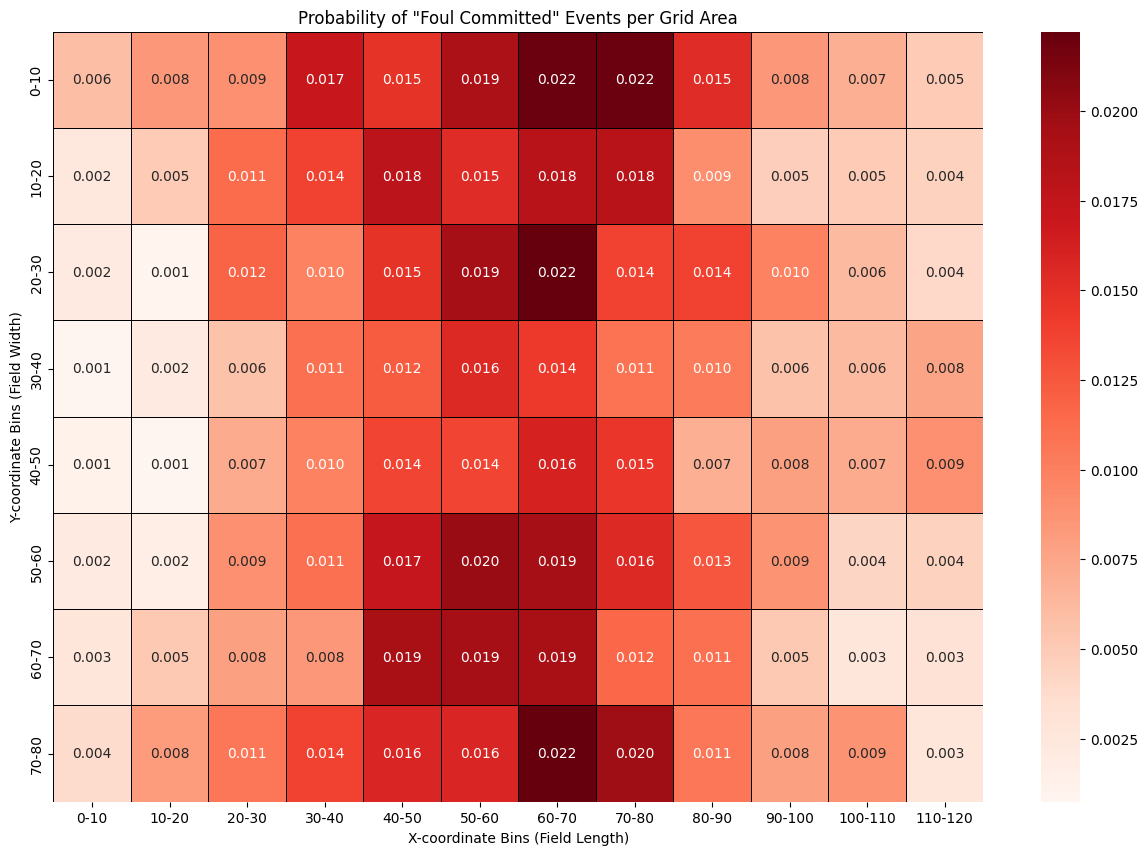

In [14]:
import numpy as np

if not foul_committed_locations.empty:
    # Define field dimensions based on typical football pitch (e.g., 120x80 units)
    x_min, x_max = 0, 120
    y_min, y_max = 0, 80

    # Define grid cell size (e.g., 10x10 units per cell)
    x_bin_size = 10
    y_bin_size = 10

    # Create bins for x and y coordinates
    x_bins = np.arange(x_min, x_max + x_bin_size, x_bin_size)
    y_bins = np.arange(y_min, y_max + y_bin_size, y_bin_size)

    # Calculate 2D histogram (counts of 'Foul Committed' events in each bin)
    # hist[i, j] will be the count for x_bin[i] to x_bin[i+1] and y_bin[j] to y_bin[j+1]
    hist, xedges, yedges = np.histogram2d(
        foul_committed_locations['x'],
        foul_committed_locations['y'],
        bins=[x_bins, y_bins],
        range=[[x_min, x_max], [y_min, y_max]]
    )

    # Normalize the histogram to get probabilities
    # Each cell's value represents the probability of a foul committed in that area
    total_fouls_committed = foul_committed_locations.shape[0]
    probability_map = hist / total_fouls_committed

    # Prepare labels for the heatmap
    x_labels = [f'{int(xedges[i])}-{int(xedges[i+1])}' for i in range(len(xedges)-1)]
    # Reverse y-labels to have 0-10 at the bottom of the plot
    y_labels = [f'{int(yedges[i])}-{int(yedges[i+1])}' for i in range(len(yedges)-1)]

    # Plot the probability heatmap
    plt.figure(figsize=(15, 10))
    sns.heatmap(probability_map.T,  # Transpose to have x-bins as columns and y-bins as rows
                cmap='Reds',
                annot=True, # Show numerical probabilities on the heatmap
                fmt=".3f", # Format annotations to 3 decimal places
                linewidths=.5,
                linecolor='black',
                xticklabels=x_labels,
                yticklabels=y_labels[::-1]) # Apply reversed labels

    plt.title('Probability of "Foul Committed" Events per Grid Area')
    plt.xlabel('X-coordinate Bins (Field Length)')
    plt.ylabel('Y-coordinate Bins (Field Width)')
    plt.gca().invert_yaxis() # Invert y-axis to display y=0 at the bottom (standard field orientation)
    plt.show()
else:
    print("Cannot create probability map: no valid 'Foul Committed' locations available.")

### Side-by-Side Comparison: 'Foul Committed' vs. 'Foul Won' Probability Maps

Now, let's create a probability map for 'Foul Won' events, similar to the one we created for 'Foul Committed' events. After that, we'll display both heatmaps side-by-side for a direct comparison of where these different types of foul events are most likely to occur on the field.

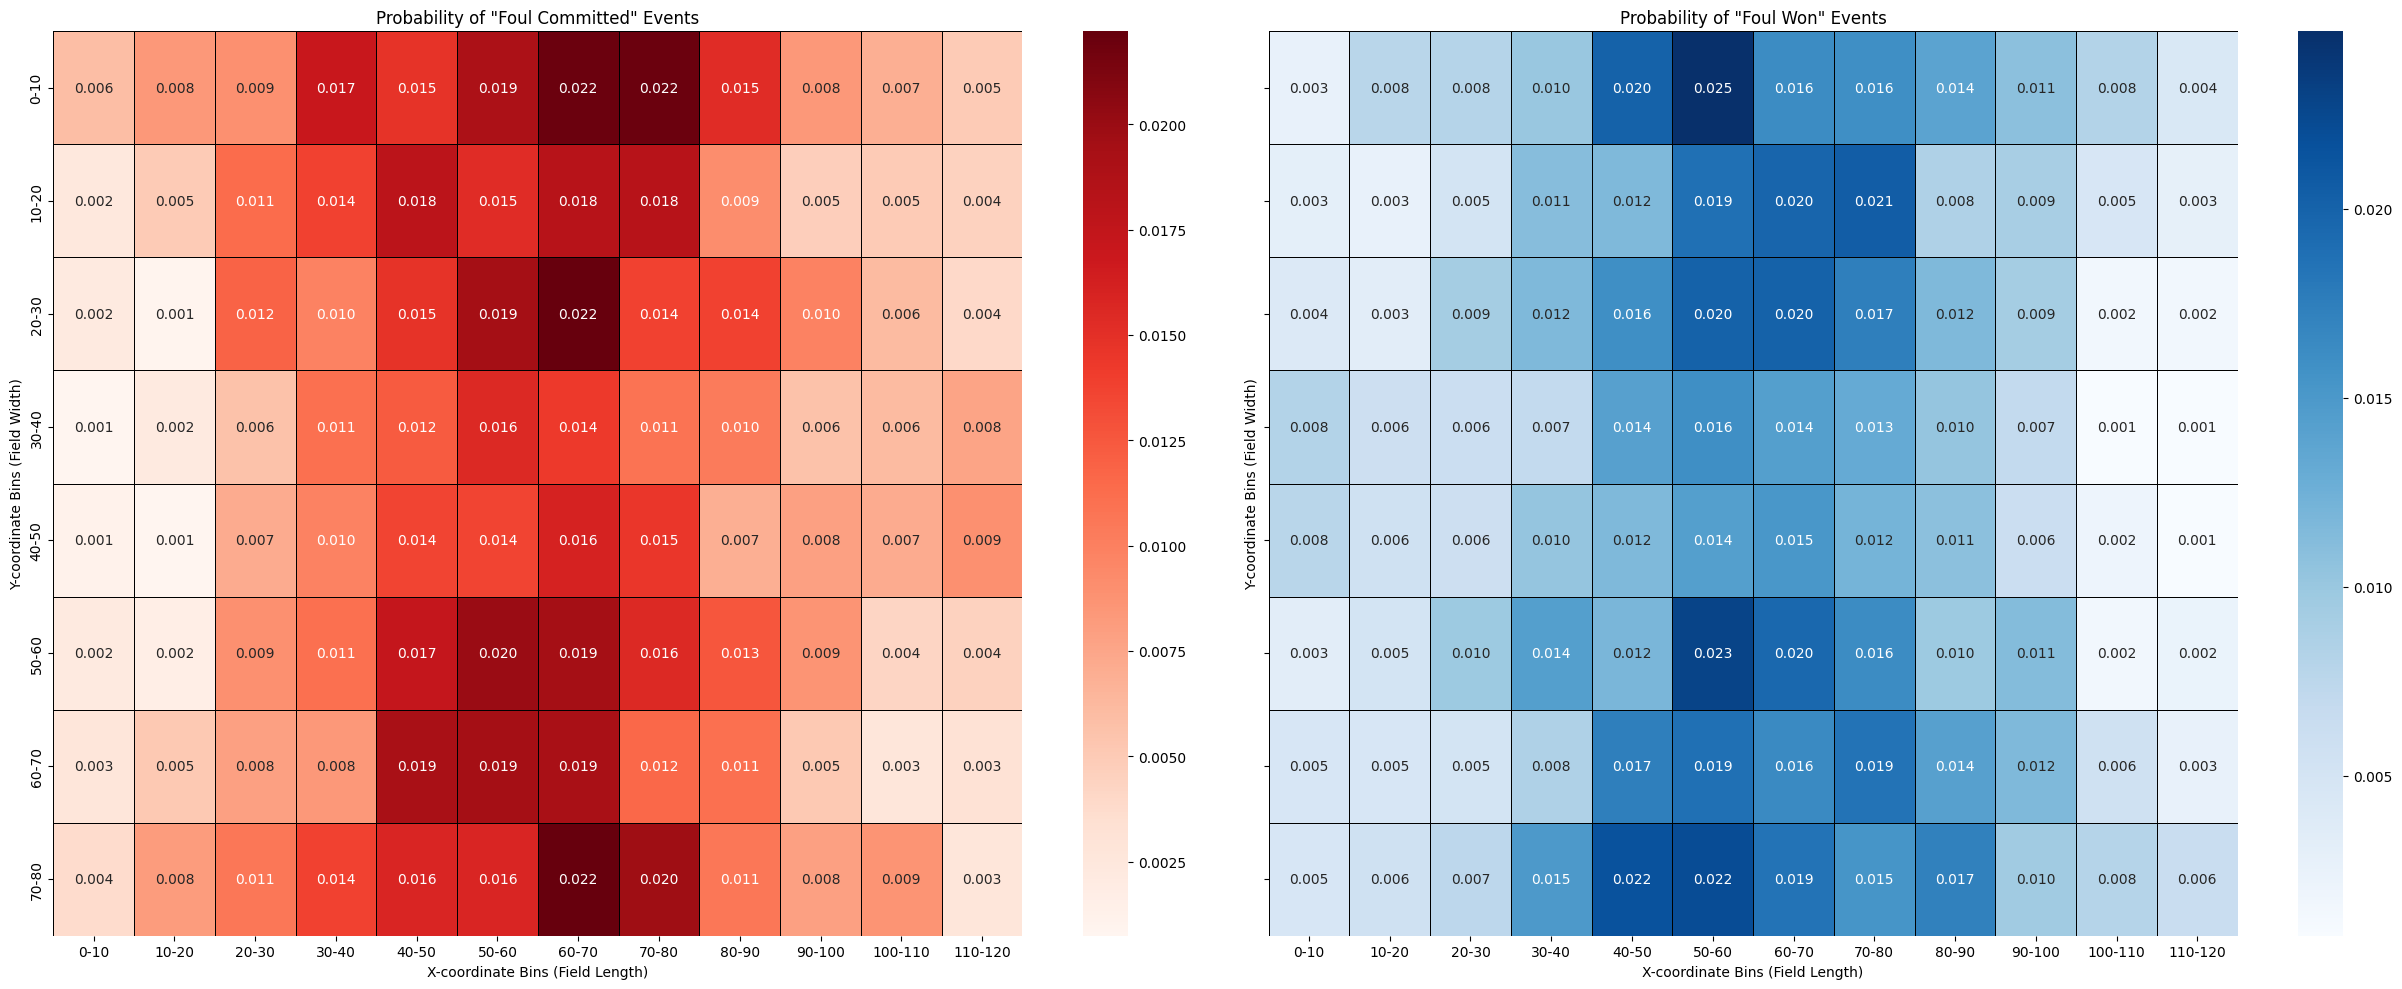

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Calculate Probability Map for 'Foul Won' Events ---
if not foul_won_locations.empty:
    x_min, x_max = 0, 120
    y_min, y_max = 0, 80
    x_bin_size = 10
    y_bin_size = 10
    x_bins = np.arange(x_min, x_max + x_bin_size, x_bin_size)
    y_bins = np.arange(y_min, y_max + y_bin_size, y_bin_size)

    hist_won, xedges_won, yedges_won = np.histogram2d(
        foul_won_locations['x'],
        foul_won_locations['y'],
        bins=[x_bins, y_bins],
        range=[[x_min, x_max], [y_min, y_max]]
    )
    total_fouls_won = foul_won_locations.shape[0]
    probability_map_won = hist_won / total_fouls_won

    x_labels_won = [f'{int(xedges_won[i])}-{int(xedges_won[i+1])}' for i in range(len(xedges_won)-1)]
    y_labels_won = [f'{int(yedges_won[i])}-{int(yedges_won[i+1])}' for i in range(len(yedges_won)-1)]
else:
    probability_map_won = np.array([])
    x_labels_won = []
    y_labels_won = []
    print("Cannot create probability map for 'Foul Won': no valid locations available.")

# --- Side-by-Side Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(25, 10), sharey=True)

# Plot for 'Foul Committed'
if not foul_committed_locations.empty:
    sns.heatmap(probability_map.T,
                cmap='Reds',
                annot=True,
                fmt=".3f",
                linewidths=.5,
                linecolor='black',
                xticklabels=x_labels,
                yticklabels=y_labels[::-1],
                ax=axes[0])
    axes[0].set_title('Probability of "Foul Committed" Events')
    axes[0].set_xlabel('X-coordinate Bins (Field Length)')
    axes[0].set_ylabel('Y-coordinate Bins (Field Width)')
    axes[0].invert_yaxis()
else:
    axes[0].set_title('No Data for "Foul Committed"')
    axes[0].axis('off') # Turn off axis if no data

# Plot for 'Foul Won'
if not foul_won_locations.empty:
    sns.heatmap(probability_map_won.T,
                cmap='Blues',
                annot=True,
                fmt=".3f",
                linewidths=.5,
                linecolor='black',
                xticklabels=x_labels_won,
                yticklabels=y_labels_won[::-1],
                ax=axes[1])
    axes[1].set_title('Probability of "Foul Won" Events')
    axes[1].set_xlabel('X-coordinate Bins (Field Length)')
    axes[1].set_ylabel('Y-coordinate Bins (Field Width)') # Re-add for clarity, though sharey=True
    axes[1].invert_yaxis()
else:
    axes[1].set_title('No Data for "Foul Won"')
    axes[1].axis('off') # Turn off axis if no data

plt.tight_layout()
plt.show()

### Optimized Probability Model: Incorporating Pressure and Time

To build a more sophisticated predictive model, we will incorporate additional features from the dataset: 'under_pressure', 'counterpress', and the 'minute' of the match. This will allow the model to learn how these factors influence the probability of a foul occurring in different areas of the field.


--- Model Performance ---
Accuracy: 0.6295
ROC AUC: 0.7274

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.62      0.63      1216
           1       0.63      0.63      0.63      1216

    accuracy                           0.63      2432
   macro avg       0.63      0.63      0.63      2432
weighted avg       0.63      0.63      0.63      2432


Model trained with a balanced dataset of foul and non-foul events.


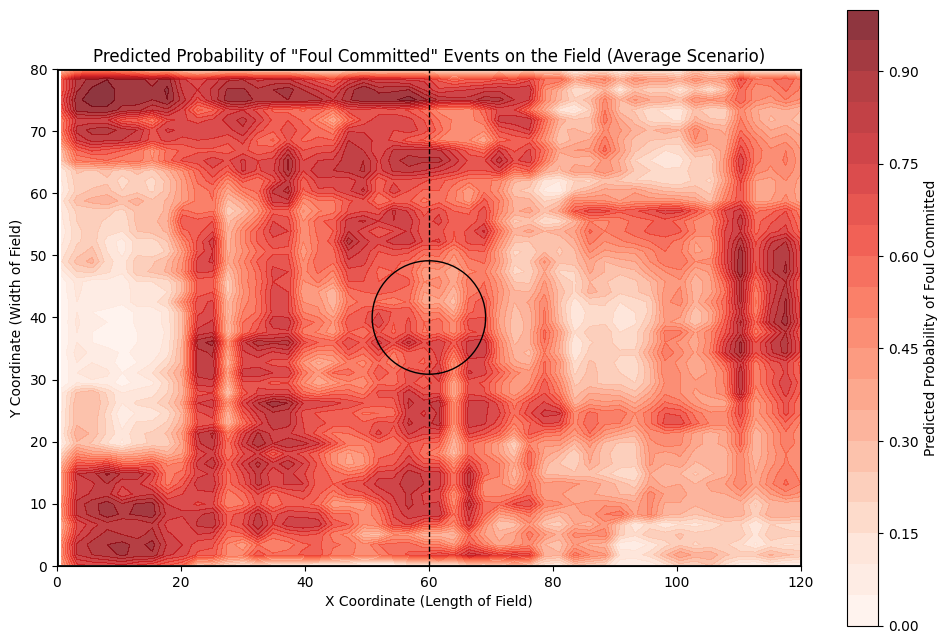

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Feature Engineering ---
# For 'Foul Committed' events, we want to predict where they are likely to happen
# We need to create a balanced dataset with both foul and non-foul events

# 1. Prepare Foul Committed events (target = 1)
foul_committed_data = foul_committed_locations.copy()
foul_committed_data['is_foul_committed'] = 1

# Convert 'under_pressure' and 'counterpress' for foul data
if 'under_pressure' in foul_committed_data.columns:
    foul_committed_data['under_pressure'] = foul_committed_data['under_pressure'].fillna(0).astype(int)
else:
    foul_committed_data['under_pressure'] = 0

if 'counterpress' in foul_committed_data.columns:
    foul_committed_data['counterpress'] = foul_committed_data['counterpress'].fillna(0).astype(int)
else:
    foul_committed_data['counterpress'] = 0

# 2. Prepare Non-Foul events (target = 0)
# Get all rows that are NOT 'Foul Committed' from the original df
# First, identify the indices of foul_committed_locations in the original df
foul_committed_indices = foul_committed_locations.index

# Filter out 'Foul Committed' events from the original dataframe
non_foul_events_df = df.drop(foul_committed_indices, errors='ignore').copy()

# Filter for relevant columns and ensure they have 'minute', 'x', 'y', 'under_pressure', 'counterpress'
# Also ensure they have parsed location if available or impute

# Let's re-parse locations for non_foul_events_df as well to ensure 'x' and 'y' are present
def parse_location(loc_str):
    try:
        return ast.literal_eval(loc_str)
    except (ValueError, SyntaxError):
        return None

non_foul_events_df['parsed_location'] = non_foul_events_df['location'].astype(str).apply(parse_location)
non_foul_events_df = non_foul_events_df[non_foul_events_df['parsed_location'].notna() &
                                        non_foul_events_df['parsed_location'].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 2)].copy()
non_foul_events_df['x'] = non_foul_events_df['parsed_location'].apply(lambda loc: loc[0])
non_foul_events_df['y'] = non_foul_events_df['parsed_location'].apply(lambda loc: loc[1])

# Sample a similar number of non-foul events as foul_committed_data for a balanced dataset
num_foul_committed = len(foul_committed_data)
if len(non_foul_events_df) > num_foul_committed:
    non_foul_sampled = non_foul_events_df.sample(n=num_foul_committed, random_state=42)
else:
    non_foul_sampled = non_foul_events_df.copy() # Use all available if fewer

non_foul_sampled['is_foul_committed'] = 0

# Convert 'under_pressure' and 'counterpress' for non-foul data
if 'under_pressure' in non_foul_sampled.columns:
    non_foul_sampled['under_pressure'] = non_foul_sampled['under_pressure'].fillna(0).astype(int)
else:
    non_foul_sampled['under_pressure'] = 0

if 'counterpress' in non_foul_sampled.columns:
    non_foul_sampled['counterpress'] = non_foul_sampled['counterpress'].fillna(0).astype(int)
else:
    non_foul_sampled['counterpress'] = 0

# Combine foul and non-foul data
model_df = pd.concat([foul_committed_data, non_foul_sampled], ignore_index=True)

# Ensure 'minute' is numerical and handle any missing values in it
model_df['minute'] = pd.to_numeric(model_df['minute'], errors='coerce').fillna(model_df['minute'].median() if not model_df['minute'].isnull().all() else 0)

# --- Select Features and Target ---
features = ['x', 'y', 'minute', 'under_pressure', 'counterpress']
target = 'is_foul_committed'

X = model_df[features]
y = model_df[target]

# --- Handle potential missing values in features (e.g., fill with median/mean or 0) ---
X = X.fillna(0)

# --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # Use stratify to maintain class balance

# --- Model Training (Random Forest Classifier) ---
# A Random Forest is suitable for this type of problem and can handle non-linear relationships.
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# --- Model Evaluation ---
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Probability of class 1 (foul committed)

print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nModel trained with a balanced dataset of foul and non-foul events.")


# --- Visualizing the Predicted Probabilities ---
# Create a grid for prediction
x_grid = np.linspace(X['x'].min(), X['x'].max(), 50)
y_grid = np.linspace(X['y'].min(), X['y'].max(), 50)
xx, yy = np.meshgrid(x_grid, y_grid)

# Prepare input for prediction: use mean values for 'minute', 'under_pressure', 'counterpress'
# Or, you can choose specific scenarios (e.g., high pressure, late in the game)
mean_minute = X['minute'].mean()
mean_under_pressure = X['under_pressure'].mean()
mean_counterpress = X['counterpress'].mean()

# Create a DataFrame for grid predictions
grid_predictions_input = pd.DataFrame({
    'x': xx.ravel(),
    'y': yy.ravel(),
    'minute': mean_minute,
    'under_pressure': mean_under_pressure,
    'counterpress': mean_counterpress
})

# Predict probabilities across the grid
Z = model.predict_proba(grid_predictions_input[features])[:, 1]
Z = Z.reshape(xx.shape)

# Plot the probability heatmap on the field
plt.figure(figsize=(12, 8))
contour = plt.contourf(xx, yy, Z, levels=20, cmap='Reds', alpha=0.8)
plt.colorbar(contour, label='Predicted Probability of Foul Committed')

# Simulate a football field outline
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.axvline(x=120, color='black', linestyle='-', linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=2)
plt.axhline(y=80, color='black', linestyle='-', linewidth=2)
plt.axvline(x=60, color='black', linestyle='--', linewidth=1)
center_circle = plt.Circle((60, 40), 9.15, color='black', fill=False)
plt.gca().add_patch(center_circle)

plt.xlim(0, 120)
plt.ylim(0, 80)
plt.title('Predicted Probability of "Foul Committed" Events on the Field (Average Scenario)')
plt.xlabel('X Coordinate (Length of Field)')
plt.ylabel('Y Coordinate (Width of Field)')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(False)
plt.show()

### Feature Importance Analysis

To understand which factors contribute most to the model's predictions, we can examine the feature importances from the trained `RandomForestClassifier`. This will tell us the relative significance of 'x', 'y', 'minute', 'under_pressure', and 'counterpress' in determining the probability of a foul being committed.

Feature Importances:


,Feature,Importance
1,y,0.308730
0,x,0.304616
2,minute,0.207926
3,under_pressure,0.098811
4,counterpress,0.079916


/tmp/ipykernel_706/1005202351.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


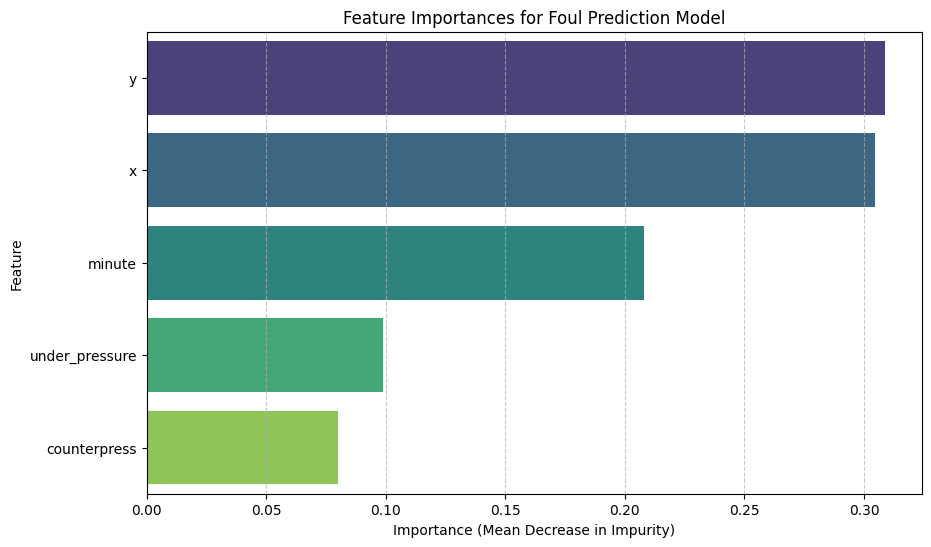

In [21]:
# Get feature importances from the trained model
importances = model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(feature_importance_df)

# Plotting feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances for Foul Prediction Model')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Visualizing the Predicted Probabilities

To visualize the predictions, we can create a grid over the field and predict the probability of a foul for each cell, considering hypothetical scenarios for 'minute', 'under_pressure', and 'counterpress'.

Let's create a heatmap that shows the predicted probability of a foul committed across the field, assuming average or default values for 'minute', 'under_pressure', and 'counterpress'.

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create interactive widgets for scenario selection
minute_slider = widgets.IntSlider(
    value=45,
    min=0,
    max=90,
    step=1,
    description='Minute:',
    continuous_update=False
)
under_pressure_toggle = widgets.Checkbox(
    value=False,
    description='Under Pressure'
)
counterpress_toggle = widgets.Checkbox(
    value=False,
    description='Counterpress'
)

output = widgets.Output()

def plot_scenario_probability(minute, under_pressure, counterpress):
    with output:
        clear_output(wait=True)
        print(f"Predicting for Minute: {minute}, Under Pressure: {under_pressure}, Counterpress: {counterpress}")

        # Create a copy of the grid_predictions_input to avoid modifying the original
        scenario_grid_predictions_input = grid_predictions_input.copy()

        # Update the scenario values for the grid
        scenario_grid_predictions_input['minute'] = minute
        scenario_grid_predictions_input['under_pressure'] = int(under_pressure)
        scenario_grid_predictions_input['counterpress'] = int(counterpress)

        # Predict probabilities across the grid for the given scenario
        Z_scenario = model.predict_proba(scenario_grid_predictions_input[features])[:, 1]
        Z_scenario = Z_scenario.reshape(xx.shape)

        # Plot the probability heatmap on the field
        plt.figure(figsize=(12, 8))
        contour = plt.contourf(xx, yy, Z_scenario, levels=20, cmap='Reds', alpha=0.8)
        plt.colorbar(contour, label='Predicted Probability of Foul Committed')

        # Simulate a football field outline
        plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
        plt.axvline(x=120, color='black', linestyle='-', linewidth=2)
        plt.axhline(y=0, color='black', linestyle='-', linewidth=2)
        plt.axhline(y=80, color='black', linestyle='-', linewidth=2)
        plt.axvline(x=60, color='black', linestyle='--', linewidth=1)
        center_circle = plt.Circle((60, 40), 9.15, color='black', fill=False)
        plt.gca().add_patch(center_circle)

        plt.xlim(0, 120)
        plt.ylim(0, 80)
        plt.title(f'Predicted Probability of "Foul Committed" Events (Minute: {minute}, Under Pressure: {under_pressure}, Counterpress: {counterpress})')
        plt.xlabel('X Coordinate (Length of Field)')
        plt.ylabel('Y Coordinate (Width of Field)')
        plt.gca().set_aspect('equal', adjustable='box')
        plt.grid(False)
        plt.show()

# Link widgets to the plotting function
widgets.interactive_output(
    plot_scenario_probability,
    {
        'minute': minute_slider,
        'under_pressure': under_pressure_toggle,
        'counterpress': counterpress_toggle
    }
)

display(minute_slider, under_pressure_toggle, counterpress_toggle, output)


IntSlider(value=45, continuous_update=False, description='Minute:', max=90)

Checkbox(value=False, description='Under Pressure')

Checkbox(value=False, description='Counterpress')

Output()

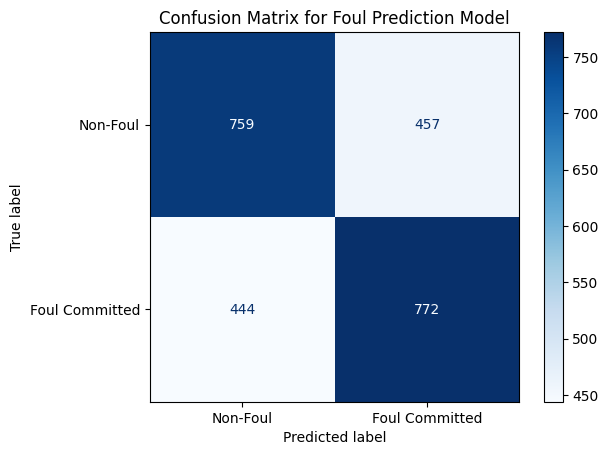

Confusion Matrix Breakdown:
True Negatives (Non-Foul correctly predicted): 759
False Positives (Non-Foul incorrectly predicted as Foul): 457
False Negatives (Foul incorrectly predicted as Non-Foul): 444
True Positives (Foul correctly predicted): 772


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Foul', 'Foul Committed'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Foul Prediction Model')
plt.show()

# Print a more detailed breakdown
print("Confusion Matrix Breakdown:")
print(f"True Negatives (Non-Foul correctly predicted): {cm[0, 0]}")
print(f"False Positives (Non-Foul incorrectly predicted as Foul): {cm[0, 1]}")
print(f"False Negatives (Foul incorrectly predicted as Non-Foul): {cm[1, 0]}")
print(f"True Positives (Foul correctly predicted): {cm[1, 1]}")